# DR-PINN Benchmark: Linear Control System with Polytopic Input Set

This notebook implements the **Section 4.2** benchmark of the paper
*Distance-Residual Physics-Informed Neural Networks* (DR-PINNs).

## Setting

We consider the linear differential inclusion

$$
\dot{x}(t) \;\in\; A\,x(t) + B\,U,
\qquad
U = \mathrm{conv}\{u_1,\ldots,u_K\} \subset \mathbb{R}^m,
\qquad x(0) = x_0,
$$

where the admissible-velocity set is

$$
F(t,x) = \mathrm{conv}(V(x)),
\qquad
V(x) = \{A x + B u_k\}_{k=1}^K.
$$

This is **regime (b)** of Section 4.2: $F$ depends on the state $x(t)$
through an affine image of a *fixed* polytope $U$.  The Quickhull reduction of $U$
is performed **once offline**, after which only a small QP (Eq. 4.4 of the paper)
is solved at each collocation point inside the training loop.

## What this notebook demonstrates

1. **Quickhull preprocessing** — reduction of a redundant vertex set to its extreme
   points, following Section 4.2 regime (b).
2. **QP projection** — evaluation of
   $\mathrm{dist}^2(\dot{x}_\theta(t), F(x_\theta(t)))$ via the small QP (4.4).
3. **Gradient flow** — the gradient
   $\nabla_v \mathrm{dist}^2(v,C) = 2(v-\Pi_C(v))$ is propagated correctly
   through TF autograd by treating $\Pi_C(v)$ as a constant at each step.
4. **Reference reachable tube** — computed by integrating with bang-bang and
   piecewise-constant random controls.
5. **Ensemble + Hausdorff distance** — multiple DR-PINNs (different seeds) form a
   PINN reachable tube; its Hausdorff distance to the reference tube is measured.
6. **Scalability study** — training-time comparisons as $K$ and $d$ grow, showing
   that Quickhull keeps the cost flat when $V(x)$ contains many redundant vertices.


## 1. Imports and configuration

In [1]:
import os
import time
import warnings
from dataclasses import dataclass

import numpy as np
import scipy.optimize
import scipy.spatial
import scipy.integrate
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
print(f'TensorFlow {tf.__version__}  |  NumPy {np.__version__}  |  SciPy {scipy.__version__}')


TensorFlow 2.10.0  |  NumPy 1.26.4  |  SciPy 1.12.0


In [34]:
# Global matplotlib style: LaTeX-like Computer Modern text at the paper's
# body-text size (14pt), applied to every figure in this notebook.
plt.rcParams.update({
    'mathtext.fontset':            'cm',
    'font.family':                 'serif',
    'font.serif':                  ['cmr10', 'Computer Modern Roman', 'DejaVu Serif'],
    'axes.formatter.use_mathtext': True,
    'font.size':                   14,
    'axes.labelsize':              14,
    'axes.titlesize':              14,
    'xtick.labelsize':             14,
    'ytick.labelsize':             14,
    'legend.fontsize':             14,
})


In [2]:
@dataclass
class Config:
    # system
    T:      float = 1.5    # time horizon
    d:      int   = 2      # state dimension (overridden in scalability study)
    # training
    seed:   int   = 42
    n_col:  int   = 300    # collocation points
    width:  int   = 64     # hidden units per layer
    depth:  int   = 3      # number of hidden layers
    lr:     float = 1e-3   # Adam learning rate
    epochs: int   = 1000
    # ensemble
    n_ensemble:   int = 5
    # reference tube
    n_ref_random: int = 300  # piecewise-constant random controls
    n_ref_t:      int = 150  # time points in reference tube
    # output
    output_dir: str = '../results/results_linear_control_qp_quickhull'


def set_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)


## 2. Problem setup

We choose a **stable spiral** as the drift matrix $A$ and the identity as $B$,
so the control acts directly in state space.  The control set is the
$\ell^1$ diamond in $\mathbb{R}^2$:

$$
U = \mathrm{conv}\{e_1, -e_1, e_2, -e_2\}.
$$

To make the Quickhull reduction non-trivial we augment the four extreme vertices
with **eight redundant interior points**, giving $K_{\mathrm{raw}} = 12$.


In [3]:
# System matrices
A_np = np.array([[-0.5,  1.0],
                 [-1.0, -0.5]], dtype=np.float64)   # stable spiral

B_np = np.eye(2, dtype=np.float64)                  # full-state actuation

x0 = np.array([1.0, 0.0], dtype=np.float64)         # initial condition

# Control set U: 4 extreme vertices (L1 diamond) + 8 interior points
U_extreme = np.array([[ 1.,  0.],
                      [ 0.,  1.],
                      [-1.,  0.],
                      [ 0., -1.]], dtype=np.float64)

rng_init  = np.random.default_rng(0)
U_interior = rng_init.uniform(-0.35, 0.35, size=(8, 2))

U_raw = np.vstack([U_extreme, U_interior])   # K_raw = 12
K_raw = len(U_raw)

print(f'A =\n{A_np}')
print(f'\nB = identity_2')
print(f'\nx0 = {x0}')
print(f'\nControl set U:  K_raw = {K_raw} vertices (4 extreme + 8 interior)')


A =
[[-0.5  1. ]
 [-1.  -0.5]]

B = identity_2

x0 = [1. 0.]

Control set U:  K_raw = 12 vertices (4 extreme + 8 interior)


## 3. Offline Quickhull preprocessing (Section 4.2, regime b)

Since $V(x) = Ax + B\,U$ is an affine image of the *fixed* set $U$, the
convex hull satisfies $\mathrm{conv}(V(x)) = Ax + B\,\mathrm{conv}(U)$.
Therefore the extreme points of $U$ can be computed **once offline**.  During
training, only the reduced set $B\widetilde{U}$ is translated by $Ax_\theta(t_i)$
at each collocation point.

**Key saving:** the downstream QP has $\tilde{K}$ variables instead of
$K_{\mathrm{raw}}$.  When many vertices are interior, the per-step cost is
independent of $K_{\mathrm{raw}}$ after the offline phase.


Quickhull:  K_raw = 12  ->  K_tilde = 4  (reduction factor 3.0x)

Extreme vertices of B*U:
[[-1.  0.]
 [ 0. -1.]
 [ 1.  0.]
 [ 0.  1.]]


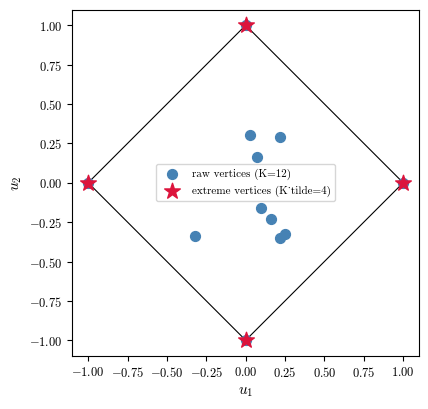

In [29]:
def compute_extreme_vertices(points):
    # Return the extreme points (convex-hull vertices) of a finite point set.
    # Uses scipy.spatial.ConvexHull, which internally calls Quickhull.
    # points : (K, d) float64 array
    # returns : (K_tilde, d) float64 array,  K_tilde <= K
    K, d = points.shape
    if K <= 1:
        return points.copy()
    if d == 1:
        return points[[np.argmin(points[:, 0]), np.argmax(points[:, 0])]]
    try:
        hull = scipy.spatial.ConvexHull(points)
        return points[hull.vertices]
    except scipy.spatial.qhull.QhullError:
        return points.copy()   # degenerate fallback


# Offline: compute extreme vertices of B * U_raw (done ONCE before training)
BU_raw     = (B_np @ U_raw.T).T          # (K_raw, d)
BU_extreme = compute_extreme_vertices(BU_raw)   # (K_tilde, d)
K_tilde    = len(BU_extreme)

print(f'Quickhull:  K_raw = {K_raw}  ->  K_tilde = {K_tilde}  '
      f'(reduction factor {K_raw/K_tilde:.1f}x)')
print(f'\nExtreme vertices of B*U:\n{BU_extreme}')

# Visualise U_raw and its convex hull
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(U_raw[:, 0], U_raw[:, 1], c='steelblue', s=50, zorder=3,
           label=f'raw vertices (K={K_raw})')
ax.scatter(BU_extreme[:, 0], BU_extreme[:, 1], c='crimson', s=140,
           marker='*', zorder=4, label=f'extreme vertices (K_tilde={K_tilde})')
hull_plt = scipy.spatial.ConvexHull(BU_raw)
for s in hull_plt.simplices:
    ax.plot(BU_raw[s, 0], BU_raw[s, 1], 'k-', lw=0.8)
ax.set_aspect('equal')
ax.set_xlabel(r'$u_1$'); ax.set_ylabel(r'$u_2$')
#ax.set_title('Control set $U$ and its convex hull')
ax.legend(fontsize=8)
#plt.tight_layout()
os.makedirs('../results/results_linear_control_qp_quickhull', exist_ok=True)
plt.savefig('../results/results_linear_control_qp_quickhull/control_set.png', dpi=180)
plt.show()


## 4. QP projection onto the convex hull (Eq. 4.4)

Given velocity $v \in \mathbb{R}^d$ and a vertex set
$\{v_1,\ldots,v_{\tilde{K}}\}$, the projection of $v$ onto
$F = \mathrm{conv}(\{v_k\})$ satisfies

$$
\Pi_F(v) = \sum_{k=1}^{\tilde{K}} \lambda_k^* v_k,
\qquad
(\lambda^*) = \arg\min_{\lambda \in \Delta_{\tilde{K}}}
\Bigl|v - \sum_k \lambda_k v_k\Bigr|^2.
$$

We solve this QP with `scipy.optimize.minimize` (SLSQP).

**Gradient.** Inside `tf.GradientTape` the projection is computed outside the TF
graph and stored as a constant tensor `proj_tf`.  The loss term is

$$
\mathrm{dist}^2(v, F) = \|v - \texttt{proj\_tf}\|^2,
$$

and TF automatically differentiates through this expression, giving

$$
\nabla_v \mathrm{dist}^2 = 2(v - \Pi_F(v)),
$$

which is the correct analytical gradient of the squared distance to a convex set.
No custom gradient hook is needed.


In [5]:
def qp_project(v, vertices):
    # Project v onto conv(vertices) by solving QP (Eq. 4.4).
    # v        : (d,) float64
    # vertices : (K, d) float64
    # returns  : (d,) float64  -- projection of v onto conv(vertices)
    K = len(vertices)
    if K == 1:
        return vertices[0].copy()
    G = vertices @ vertices.T    # Gram matrix (K, K)
    c = vertices @ v             # linear term (K,)
    res = scipy.optimize.minimize(
        fun=lambda lam: float(lam @ G @ lam) - 2.0 * float(c @ lam),
        x0=np.ones(K) / K,
        jac=lambda lam: 2.0 * (G @ lam) - 2.0 * c,
        method='SLSQP',
        bounds=[(0., 1.)] * K,
        constraints={'type': 'eq', 'fun': lambda lam: lam.sum() - 1.},
        options={'ftol': 1e-12, 'maxiter': 300}
    )
    lam = np.clip(res.x, 0., 1.)
    lam /= lam.sum()
    return vertices.T @ lam


def project_batch(v_batch, vertex_sets):
    # Project each v_batch[i] onto conv(vertex_sets[i]).
    # v_batch     : (N, d) float64
    # vertex_sets : (N, K, d) float64
    # returns     : (N, d) float64
    N = v_batch.shape[0]
    projs = np.empty_like(v_batch)
    for i in range(N):
        projs[i] = qp_project(v_batch[i], vertex_sets[i])
    return projs


In [6]:
# Sanity check: project onto a triangle
tri = np.array([[0., 0.], [1., 0.], [0., 1.]], dtype=np.float64)
for desc, v in [('inside  (0.2, 0.2)', np.array([0.2, 0.2])),
                ('outside (2.0, 0.0)', np.array([2.0, 0.0])),
                ('outside (-0.5, 0.5)', np.array([-0.5, 0.5]))]:
    p = qp_project(v, tri)
    d = np.linalg.norm(v - p)
    print(f'  {desc}  ->  proj = ({p[0]:.4f}, {p[1]:.4f}),  dist = {d:.4f}')


  inside  (0.2, 0.2)  ->  proj = (0.2000, 0.2000),  dist = 0.0000
  outside (2.0, 0.0)  ->  proj = (1.0000, 0.0000),  dist = 1.0000
  outside (-0.5, 0.5)  ->  proj = (0.0000, 0.5000),  dist = 0.5000


## 5. Neural network with hard initial condition

The network $N_\theta : \mathbb{R} \to \mathbb{R}^d$ has tanh activations.
The **trial solution**

$$
x_\theta(t) = x_0 + t\,N_\theta(t)
$$

satisfies $x_\theta(0) = x_0$ exactly for any $\theta$.
The time derivative $\dot{x}_\theta(t)$ is computed by
`tf.GradientTape.batch_jacobian`.


In [7]:
def build_network(d_out, width=64, depth=3):
    # Fully-connected tanh network.
    # Input: t in R  (shape (N, 1))
    # Output: N_theta(t) in R^d  (shape (N, d_out))
    inp = tf.keras.Input(shape=(1,))
    z = inp
    for _ in range(depth):
        z = tf.keras.layers.Dense(
            width, activation='tanh',
            kernel_initializer='glorot_normal',
            bias_initializer='zeros'
        )(z)
    out = tf.keras.layers.Dense(
        d_out, activation=None,
        kernel_initializer='glorot_normal',
        bias_initializer='zeros'
    )(z)
    return tf.keras.Model(inp, out)


class TrialSolution(tf.keras.Model):
    # Hard enforcement of x(0) = x0 via x_theta(t) = x0 + t * N_theta(t).

    def __init__(self, x0, width=64, depth=3):
        super().__init__()
        self.x0 = tf.constant(x0, dtype=tf.float32)
        self.d  = len(x0)
        self.N  = build_network(d_out=self.d, width=width, depth=depth)

    def call(self, t, training=False):
        # t : (batch, 1)  ->  x : (batch, d)
        return self.x0 + t * self.N(t, training=training)


## 6. DR-PINN loss with QP projection inside the training loop

At each step the loss is

$$
\mathcal{L}_F(\theta)
= \frac{1}{N} \sum_{i=1}^N
  \bigl|\dot{x}_\theta(t_i) - \Pi_{F_i}\bigl(\dot{x}_\theta(t_i)\bigr)\bigr|^2,
\qquad
F_i = \mathrm{conv}\bigl(\{A x_\theta(t_i) + v\}_{v \in B\widetilde{U}}\bigr).
$$

**Implementation flow:**
1. Forward + AD: $x_\theta(t_i)$, $\dot{x}_\theta(t_i)$ via `batch_jacobian`.
2. Build vertex sets $V_i = Ax_\theta(t_i) + B\widetilde{U}$ (NumPy, outside TF).
3. Solve QP batch: $\Pi_i$ (SciPy, outside TF).
4. Compute loss: $\tfrac{1}{N}\sum_i|\dot{x}_\theta(t_i) - \Pi_i|^2$ (TF, with $\Pi_i$ as constant).
5. TF backprop gives gradient $2(\dot{x}_\theta(t_i)-\Pi_i)/N$ — the correct
   gradient of the squared distance.


In [8]:
def compute_vertex_sets(x_np, A, BU_ext):
    # Build vertex sets V_i = {A x_i + v : v in BU_ext}.
    # x_np   : (N, d) float64
    # A      : (d, d) float64
    # BU_ext : (K_tilde, d) float64
    # returns: (N, K_tilde, d) float64
    Ax = x_np @ A.T                                  # (N, d)
    return Ax[:, np.newaxis, :] + BU_ext[np.newaxis, :, :]


def compute_dr_loss(model, t_col, A, BU_ext):
    # Evaluate the DR-PINN inclusion loss and return diagnostics.
    # Returns: (loss, dx, projs)
    #   loss  : scalar tf.Tensor to minimise
    #   dx    : (N, d) tf.Tensor -- learned velocities
    #   projs : (N, d) np.ndarray -- QP projections
    with tf.GradientTape() as tape:
        tape.watch(t_col)
        x = model(t_col, training=True)              # (N, d)

    dx_raw = tape.batch_jacobian(x, t_col)           # (N, d, 1)
    dx     = dx_raw[:, :, 0]                         # (N, d)

    x_np  = x.numpy().astype(np.float64)
    dx_np = dx.numpy().astype(np.float64)

    vsets = compute_vertex_sets(x_np, A, BU_ext)    # (N, K_tilde, d)
    projs = project_batch(dx_np, vsets)              # (N, d)

    # dist^2 loss -- projs treated as a constant by TF autograd.
    # TF computes gradient 2*(dx - projs)/N, which equals
    # the analytical gradient of dist^2(v, conv(V)) w.r.t. v.
    projs_tf = tf.constant(projs, dtype=tf.float32)
    diff     = dx - projs_tf                         # (N, d)
    loss     = tf.reduce_mean(tf.reduce_sum(diff**2, axis=-1))

    return loss, dx, projs


## 7. Training loop

In [9]:
def train_dr_pinn(model, cfg, A, BU_ext, verbose=True):
    # Train the DR-PINN by minimising the inclusion loss L_F.
    # Returns history dict with keys 'loss' and 'time_per_epoch'.
    t_col = tf.cast(
        tf.reshape(tf.linspace(0., cfg.T, cfg.n_col), (-1, 1)),
        tf.float32
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=cfg.lr)
    history = {'loss': [], 'time_per_epoch': []}
    log_every = max(1, cfg.epochs // 10)

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.perf_counter()

        with tf.GradientTape() as tape:
            loss, _, _ = compute_dr_loss(model, t_col, A, BU_ext)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        dt = time.perf_counter() - t0
        history['loss'].append(float(loss))
        history['time_per_epoch'].append(dt)

        if verbose and (epoch == 1 or epoch % log_every == 0):
            print(f'  Epoch {epoch:5d} | loss = {float(loss):.4e} '
                  f'| {dt*1e3:.1f} ms/epoch')

    return history


## 8. Reference reachable tube

For a linear system with polytopic $U$ the **reachable tube**

$$
\mathcal{R}(t)
= \bigl\{x(t) : \dot{x} = Ax + Bu,\; u(s)\in U\text{ a.e.},\;x(0)=x_0\bigr\}
$$

is approximated by integrating two families of controls:

1. **Constant bang-bang** — one trajectory per vertex $u_k$ (extremal by
   Pontryagin's maximum principle for linear systems).
2. **Piecewise-constant random** — random sequences of vertex controls with
   random switching times, densely sampling $\mathcal{R}(t)$.


In [10]:
def compute_reference_tube(A, B, U_vertices, x0, T,
                            n_random=300, n_t=200, seed=0):
    # Compute an inner approximation of R(t) by ODE integration.
    # Returns: (t_grid, tube)
    #   t_grid : (n_t,) array
    #   tube   : (n_traj, n_t, d) array
    rng_ref = np.random.default_rng(seed)
    K  = len(U_vertices)
    t_grid = np.linspace(0., T, n_t)
    trajectories = []

    # Family 1: constant bang-bang (one per vertex)
    for k in range(K):
        uk = U_vertices[k].copy()
        sol = scipy.integrate.solve_ivp(
            lambda t, x, u=uk: A @ x + B @ u,
            [0., T], x0, t_eval=t_grid,
            method='RK45', rtol=1e-9, atol=1e-11
        )
        trajectories.append(sol.y.T)

    # Family 2: piecewise-constant random controls
    for _ in range(n_random):
        n_seg = rng_ref.integers(3, 12)
        ts    = np.concatenate([[0.],
                                 np.sort(rng_ref.uniform(0., T, n_seg - 1)),
                                 [T]])
        ks    = rng_ref.integers(0, K, size=n_seg)
        x_curr = x0.copy()
        traj   = np.zeros((n_t, len(x0)))

        for j in range(n_seg):
            ta, tb = ts[j], ts[j + 1]
            uk = U_vertices[ks[j]]
            mask  = (t_grid >= ta - 1e-12) & (t_grid <= tb + 1e-12)
            t_seg = t_grid[mask]
            if len(t_seg) < 1:
                continue
            sol = scipy.integrate.solve_ivp(
                lambda t, x, u=uk: A @ x + B @ u,
                [ta, tb], x_curr,
                t_eval=t_seg, method='RK45', rtol=1e-9, atol=1e-11
            )
            traj[mask] = sol.y.T
            x_curr = sol.y[:, -1].copy()

        trajectories.append(traj)

    return t_grid, np.array(trajectories)   # (n_traj, n_t, d)


## 9. Main 2D experiment  ($d=2$, $K_{\mathrm{raw}}=12$, $\tilde{K}=4$)

We train a single DR-PINN and overlay its trajectory with the reference
reachable tube.


In [11]:
cfg = Config()
set_seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)

print('Training single DR-PINN  (d=2, K_raw=12, K_tilde=4) ...')
model_single = TrialSolution(x0, width=cfg.width, depth=cfg.depth)
hist_single  = train_dr_pinn(model_single, cfg, A_np, BU_extreme)


Training single DR-PINN  (d=2, K_raw=12, K_tilde=4) ...
  Epoch     1 | loss = 2.1118e-01 | 985.1 ms/epoch
  Epoch   100 | loss = 4.7430e-07 | 1157.7 ms/epoch
  Epoch   200 | loss = 9.7725e-08 | 1143.4 ms/epoch
  Epoch   300 | loss = 2.7814e-08 | 1160.0 ms/epoch
  Epoch   400 | loss = 1.0220e-08 | 1154.4 ms/epoch
  Epoch   500 | loss = 3.2859e-09 | 1146.4 ms/epoch
  Epoch   600 | loss = 8.9440e-10 | 1149.7 ms/epoch
  Epoch   700 | loss = 2.0743e-10 | 1163.0 ms/epoch
  Epoch   800 | loss = 4.1312e-11 | 1149.4 ms/epoch
  Epoch   900 | loss = 7.2615e-12 | 1179.5 ms/epoch
  Epoch  1000 | loss = 1.1637e-12 | 1178.3 ms/epoch


### Training history

As a first diagnostic, we check that the inclusion loss $\mathcal{L}_F(\theta)$
has converged to (near) zero before evaluating the learned trajectory.


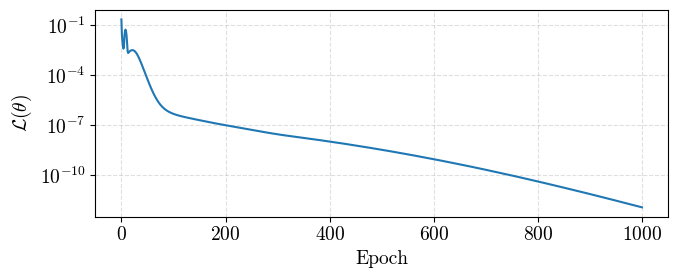

In [32]:
# Training loss curve
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(hist_single['loss'])
ax.set_xlabel('Epoch')
ax.set_ylabel(r'$\mathcal{L}(\theta)$')
#ax.set_title('Training history -- single DR-PINN')
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'loss_single.png'), dpi=180)
plt.show()


### Trajectory evaluation and reference tube

We now evaluate the trained model $x_\theta(t)$ on a fine time grid and
compute the reference reachable tube $\mathcal{R}(t)$ (Section 8), which are
both needed for the phase-portrait comparison below.


In [17]:
# Evaluate on a fine time grid
t_eval = tf.cast(tf.reshape(tf.linspace(0., cfg.T, 500), (-1, 1)), tf.float32)
x_pred = model_single(t_eval, training=False).numpy()   # (500, 2)
t_np   = t_eval.numpy().ravel()

# Compute reference reachable tube
print('\nComputing reference reachable tube ...')
t_ref, tube = compute_reference_tube(
    A_np, B_np, U_extreme, x0, cfg.T,
    n_random=cfg.n_ref_random,
    n_t=cfg.n_ref_t,
    seed=0
)
print(f'  {tube.shape[0]} reference trajectories computed.')



Computing reference reachable tube ...
  304 reference trajectories computed.


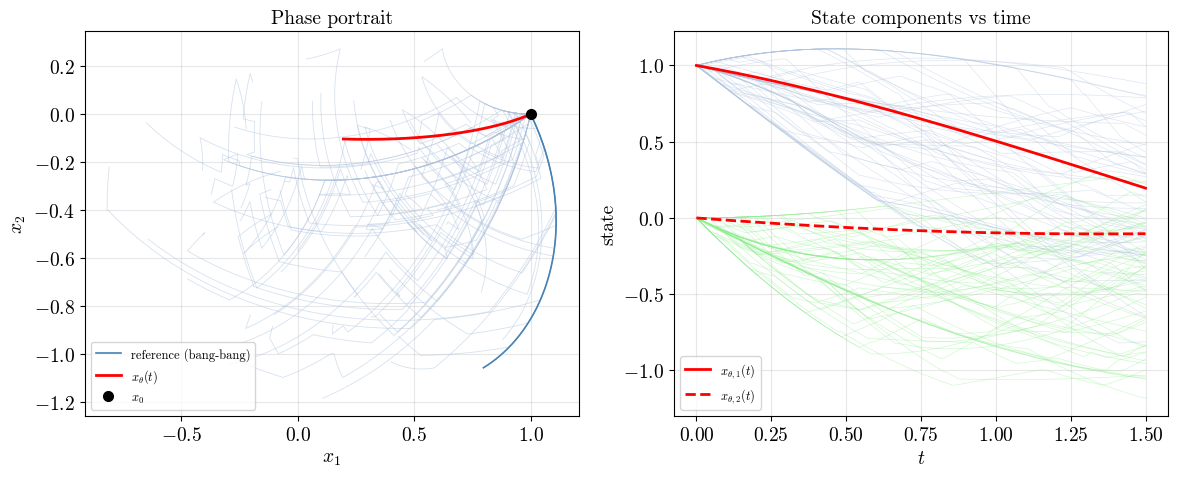

In [35]:
# Phase portrait + state components vs time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for traj in tube[::5]:
    ax.plot(traj[:, 0], traj[:, 1], color='lightsteelblue', lw=0.6, alpha=0.5)
ax.plot(tube[0, :, 0], tube[0, :, 1], color='steelblue', lw=1.2,
        label='reference (bang-bang)')
ax.plot(x_pred[:, 0], x_pred[:, 1], 'r-', lw=2.0, label=r'$x_\theta(t)$')
ax.plot(*x0, 'ko', ms=7, zorder=5, label=r'$x_0$')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.set_title('Phase portrait')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for traj in tube[::5]:
    ax.plot(t_ref, traj[:, 0], color='lightsteelblue', lw=0.5, alpha=0.4)
    ax.plot(t_ref, traj[:, 1], color='lightgreen',     lw=0.5, alpha=0.4)
ax.plot(t_np, x_pred[:, 0], 'r-',  lw=2., label=r'$x_{\theta,1}(t)$')
ax.plot(t_np, x_pred[:, 1], 'r--', lw=2., label=r'$x_{\theta,2}(t)$')
ax.set_xlabel(r'$t$'); ax.set_ylabel('state')
ax.set_title('State components vs time')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

#plt.suptitle(r'DR-PINN trajectory vs reference reachable tube'
#             r'  ($d=2,\;K_{\mathrm{raw}}=12,\;\tilde{K}=4$)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'trajectory_vs_tube.png'),
            dpi=180, bbox_inches='tight')
plt.show()


## 10. Ensemble admissibility check (Hausdorff distance)

A single DR-PINN samples **one** element of $\mathcal{S}(x_0)$, so its distance to the
reference tube is not, by itself, a robust check. We train an ensemble of DR-PINNs
(different seeds) and measure the **one-sided Hausdorff distance**

$$
d_H^+(A, B) = \max_{a \in A} \min_{b \in B} \|a - b\|.
$$

from the PINN ensemble $\mathcal{R}_\theta(t) = \{x_\theta^{(s)}(t) : s=1,\ldots,n_{\rm ens}\}$
to the reference tube $\mathcal{R}(t)$:

* $d_H^+(\mathcal{R}_\theta(t), \mathcal{R}(t))$ measures how far the PINN
  trajectories are from the reference (admissibility error), averaged over the
  ensemble and over time.


In [19]:
def one_sided_hausdorff(A_pts, B_pts):
    # max_{a in A_pts} min_{b in B_pts} ||a - b||
    # A_pts : (n_A, d),  B_pts : (n_B, d)
    diffs = A_pts[:, np.newaxis, :] - B_pts[np.newaxis, :, :]
    dists = np.sqrt(np.sum(diffs**2, axis=-1))
    return float(np.max(np.min(dists, axis=1)))


# Train ensemble
print(f'Training ensemble of {cfg.n_ensemble} DR-PINNs ...')
ensemble_trajs = []

for s in range(cfg.n_ensemble):
    seed_s = cfg.seed + s * 100
    set_seed(seed_s)
    m = TrialSolution(x0, width=cfg.width, depth=cfg.depth)
    print(f'\n  [seed {seed_s}]')
    h = train_dr_pinn(m, cfg, A_np, BU_extreme, verbose=True)
    xp = m(t_eval, training=False).numpy()
    ensemble_trajs.append(xp)

ensemble_arr = np.array(ensemble_trajs)   # (n_ens, 500, 2)
print(f'\nEnsemble shape: {ensemble_arr.shape}')


Training ensemble of 5 DR-PINNs ...

  [seed 42]
  Epoch     1 | loss = 6.3287e-02 | 762.0 ms/epoch
  Epoch   100 | loss = 7.8907e-15 | 1153.7 ms/epoch
  Epoch   200 | loss = 8.7419e-15 | 1085.0 ms/epoch
  Epoch   300 | loss = 8.7419e-15 | 1082.9 ms/epoch
  Epoch   400 | loss = 8.7419e-15 | 1075.4 ms/epoch
  Epoch   500 | loss = 8.7419e-15 | 1082.8 ms/epoch
  Epoch   600 | loss = 8.7419e-15 | 1078.3 ms/epoch
  Epoch   700 | loss = 8.7419e-15 | 1094.4 ms/epoch
  Epoch   800 | loss = 8.7419e-15 | 1088.0 ms/epoch
  Epoch   900 | loss = 8.7419e-15 | 1089.3 ms/epoch
  Epoch  1000 | loss = 8.7419e-15 | 1085.7 ms/epoch

  [seed 142]
  Epoch     1 | loss = 4.4265e-02 | 1064.7 ms/epoch
  Epoch   100 | loss = 8.2837e-15 | 1057.4 ms/epoch
  Epoch   200 | loss = 8.3459e-15 | 1058.3 ms/epoch
  Epoch   300 | loss = 8.3459e-15 | 1116.7 ms/epoch
  Epoch   400 | loss = 8.3459e-15 | 1383.1 ms/epoch
  Epoch   500 | loss = 8.3459e-15 | 1298.5 ms/epoch
  Epoch   600 | loss = 8.3459e-15 | 1173.9 ms/epoch
  

In [23]:
from scipy.interpolate import interp1d

# Interpolate reference tube to the ensemble time grid
tube_interp = np.zeros((tube.shape[0], len(t_np), 2))
for j in range(tube.shape[0]):
    for dim in range(2):
        f = interp1d(t_ref, tube[j, :, dim], kind='linear')
        tube_interp[j, :, dim] = f(t_np)

# Admissibility error: Hausdorff distance from the ensemble to the reference tube
hd_pinn_to_ref = np.zeros(len(t_np))
for ti in range(len(t_np)):
    pinn_pts = ensemble_arr[:, ti, :]
    ref_pts  = tube_interp[:, ti, :]
    hd_pinn_to_ref[ti] = one_sided_hausdorff(pinn_pts, ref_pts)

print(f'Mean d_H(PINN -> ref) = {hd_pinn_to_ref.mean():.4f}')


Mean d_H(PINN -> ref) = 0.0445


## 11. Computational scalability study

### 11a. Scalability in $K$ (fixed $d=2$)

For each $K_{\mathrm{raw}} \in \{8, 16, 32, 64, 128\}$ we generate a random
point cloud (a few on the boundary, many interior) and measure:

* $\tilde{K}$ = number of extreme points after Quickhull,
* training time per epoch **with** Quickhull (QP of size $\tilde{K}$),
* training time per epoch **without** Quickhull (QP of size $K_{\mathrm{raw}}$).

When vertices are mostly interior, Quickhull collapses $K_{\mathrm{raw}}$
to a small constant $\tilde{K}$, keeping the per-step cost flat.


In [24]:
K_values        = [8, 16, 32, 64, 128]
K_tilde_values  = []
time_with_qh    = []
time_without_qh = []
N_TIMING_EPOCHS = 50   # use a small number of epochs for timing

for K_r in K_values:
    rng_sc = np.random.default_rng(K_r)
    # Boundary points
    angles = np.linspace(0, 2*np.pi, 6, endpoint=False)
    U_bnd  = np.column_stack([np.cos(angles), np.sin(angles)])
    # Interior points (redundant)
    U_int  = rng_sc.uniform(-0.4, 0.4, (max(K_r - 6, 0), 2))
    U_sc   = np.vstack([U_bnd, U_int])[:K_r]

    BU_sc_raw = (B_np @ U_sc.T).T
    BU_sc_ext = compute_extreme_vertices(BU_sc_raw)
    Kt = len(BU_sc_ext)
    K_tilde_values.append(Kt)

    cfg_sc = Config(epochs=N_TIMING_EPOCHS, n_col=100)
    set_seed(0)

    m1 = TrialSolution(x0, width=cfg.width, depth=cfg.depth)
    h1 = train_dr_pinn(m1, cfg_sc, A_np, BU_sc_ext, verbose=False)
    time_with_qh.append(np.mean(h1['time_per_epoch']) * 1e3)

    m2 = TrialSolution(x0, width=cfg.width, depth=cfg.depth)
    h2 = train_dr_pinn(m2, cfg_sc, A_np, BU_sc_raw, verbose=False)
    time_without_qh.append(np.mean(h2['time_per_epoch']) * 1e3)

    print(f'  K_raw={K_r:3d}  K_tilde={Kt:2d}  '
          f'| w/ QH = {time_with_qh[-1]:6.1f} ms  '
          f'| w/o QH = {time_without_qh[-1]:6.1f} ms')


  K_raw=  8  K_tilde= 6  | w/ QH =  759.9 ms  | w/o QH =  887.6 ms
  K_raw= 16  K_tilde= 6  | w/ QH =  850.6 ms  | w/o QH =  949.9 ms
  K_raw= 32  K_tilde= 6  | w/ QH =  847.7 ms  | w/o QH = 1074.8 ms
  K_raw= 64  K_tilde= 6  | w/ QH =  828.6 ms  | w/o QH = 1755.9 ms
  K_raw=128  K_tilde= 6  | w/ QH =  852.5 ms  | w/o QH = 7069.4 ms


In [ ]:
# Quickhull reduction table (K_tilde vs K_raw) -- ready to paste into the paper.
header    = ' & '.join(str(k) for k in K_values)
row_tilde = ' & '.join(str(k) for k in K_tilde_values)
latex_table = (
    r'\begin{tabular}{l' + 'c' * len(K_values) + '}' + '\n'
    r'\hline' + '\n'
    r'$K_{\mathrm{raw}}$ & ' + header + r' \\' + '\n'
    r'$\tilde{K}$        & ' + row_tilde + r' \\' + '\n'
    r'\hline' + '\n'
    r'\end{tabular}'
)
print(latex_table)


### 11b. Scalability in $d$ (fixed $K_{\mathrm{raw}}=32$)

For $d \in \{2, 4, 6, 8\}$ we build a random stable linear system and a
random polytopic control set.  In higher dimensions more vertices can be
extreme (the convex hull of a random polytope in $\mathbb{R}^d$ tends to
retain more vertices), so the Quickhull benefit diminishes as $d$ grows
relative to $K_{\mathrm{raw}}$.


In [25]:
d_values       = [2, 4, 6, 8]
K_raw_d        = 32
K_tilde_d_vals = []
time_qh_d      = []
time_no_qh_d   = []

for d in d_values:
    rng_d = np.random.default_rng(d + 100)

    # Random stable matrix (dominant-diagonal construction)
    A_d = rng_d.standard_normal((d, d)) * 0.3
    A_d -= (np.abs(A_d).sum(axis=1)[:, None] + 0.5) * np.eye(d)

    B_d  = np.eye(d, dtype=np.float64)
    x0_d = np.zeros(d); x0_d[0] = 1.0

    U_d       = rng_d.uniform(-1., 1., (K_raw_d, d))
    BU_d_raw  = (B_d @ U_d.T).T
    BU_d_ext  = compute_extreme_vertices(BU_d_raw)
    Kt = len(BU_d_ext)
    K_tilde_d_vals.append(Kt)

    cfg_d = Config(d=d, epochs=N_TIMING_EPOCHS, n_col=100)
    set_seed(0)

    m1 = TrialSolution(x0_d, width=cfg.width, depth=cfg.depth)
    h1 = train_dr_pinn(m1, cfg_d, A_d, BU_d_ext, verbose=False)
    time_qh_d.append(np.mean(h1['time_per_epoch']) * 1e3)

    m2 = TrialSolution(x0_d, width=cfg.width, depth=cfg.depth)
    h2 = train_dr_pinn(m2, cfg_d, A_d, BU_d_raw, verbose=False)
    time_no_qh_d.append(np.mean(h2['time_per_epoch']) * 1e3)

    print(f'  d={d}  K_raw={K_raw_d}  K_tilde={Kt:2d}  '
          f'| w/ QH = {time_qh_d[-1]:6.1f} ms  '
          f'| w/o QH = {time_no_qh_d[-1]:6.1f} ms')


  d=2  K_raw=32  K_tilde=12  | w/ QH =  864.4 ms  | w/o QH = 1214.9 ms
  d=4  K_raw=32  K_tilde=23  | w/ QH = 1235.7 ms  | w/o QH = 1339.5 ms
  d=6  K_raw=32  K_tilde=32  | w/ QH = 1614.2 ms  | w/o QH = 1558.3 ms
  d=8  K_raw=32  K_tilde=32  | w/ QH = 1479.8 ms  | w/o QH = 1558.4 ms


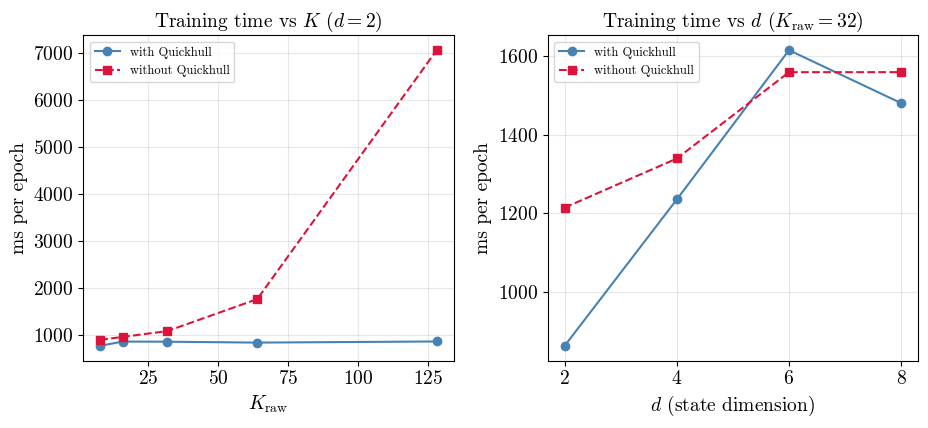

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))

# (a) time vs K
ax = axes[0]
ax.plot(K_values, time_with_qh,    'o-',  color='steelblue', label='with Quickhull')
ax.plot(K_values, time_without_qh, 's--', color='crimson',   label='without Quickhull')
ax.set_xlabel(r'$K_{\mathrm{raw}}$'); ax.set_ylabel('ms per epoch')
ax.set_title(r'Training time vs $K$ ($d=2$)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (b) time vs d
ax = axes[1]
ax.plot(d_values, time_qh_d,    'o-',  color='steelblue', label='with Quickhull')
ax.plot(d_values, time_no_qh_d, 's--', color='crimson',   label='without Quickhull')
ax.set_xlabel(r'$d$ (state dimension)'); ax.set_ylabel('ms per epoch')
ax.set_title(r'Training time vs $d$ ($K_{\mathrm{raw}}=32$)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'scalability.png'),
            dpi=180, bbox_inches='tight')
plt.show()


## 12. Summary and interpretation

| Diagnostic | What to look for |
|---|---|
| **Loss curve** | $\mathcal{L}_F(\theta) \to 0$, confirming $\dot{x}_\theta(t) \in F(x_\theta(t))$ a.e. |
| **Phase portrait** | Learned trajectory inside the reference reachable tube. |
| **$d_H^+(\mathcal{R}_\theta, \mathcal{R})$** | Admissibility error: how far the PINN trajectories are from the reference. |
| **Quickhull benefit** | "With QH" curve flat as $K_{\mathrm{raw}}$ grows; "without QH" grows linearly. |

### Connection to the paper

* **Section 4.2, regime (b):** $V(x) = Ax + B\widetilde{U}$ — the exact case
  implemented here.  Offline Quickhull reduces $K_{\mathrm{raw}} \to \tilde{K}$;
  only the small QP of size $\tilde{K}$ runs per step.
* **Equation (4.4):** the QP in `qp_project()`.
* **Theorem 4.4 (Consistency):** vanishing loss $\Rightarrow$ admissible trajectory,
  explaining why the learned trajectory stays inside $\mathcal{R}(t)$.
* **Section 2.3 (non-uniqueness):** different seeds produce different admissible
  trajectories, all contained in $\mathcal{R}(t)$.
